In [1]:
import sinter
import stim
from typing import List
import matplotlib.pyplot as plt

In [2]:
noise = [
    0.003,
    0.004,
    0.005,
    0.006,
    0.0065,
    0.007,
    0.0075,
    0.008,
    0.009,
    0.01,
    0.015,
    0.05,
    0.08,
    0.09,
    0.1,
    0.2,
]
code_distance = [3, 5, 7, 9]
MAX_SHOTS = 100000
MAX_ERRORS = 1000

In [3]:
# `rotated_memory_x` (surface_code):
# Initialize a logical `|+>` in a rotated surface code,
# preserve it against noise for the given number of rounds,
# then measure in the X basis.
task_configs = [
    dict(
        circuit=stim.Circuit.generated(
            "surface_code:rotated_memory_x",
            rounds=d * 3,
            distance=d,
            before_round_data_depolarization=p,
            after_clifford_depolarization=p,
        ),
        json_metadata={"d": d, "p": p, "label": "rotated_memory_x"},
    )
    for d in code_distance
    for p in noise
]
tasks = [sinter.Task(**task) for task in task_configs]

pymatching_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=10,
    tasks=tasks,
    decoders=["pymatching"],
    max_shots=MAX_SHOTS,
    max_errors=MAX_ERRORS,
    count_observable_error_combos=True,
    count_detection_events=True,
)

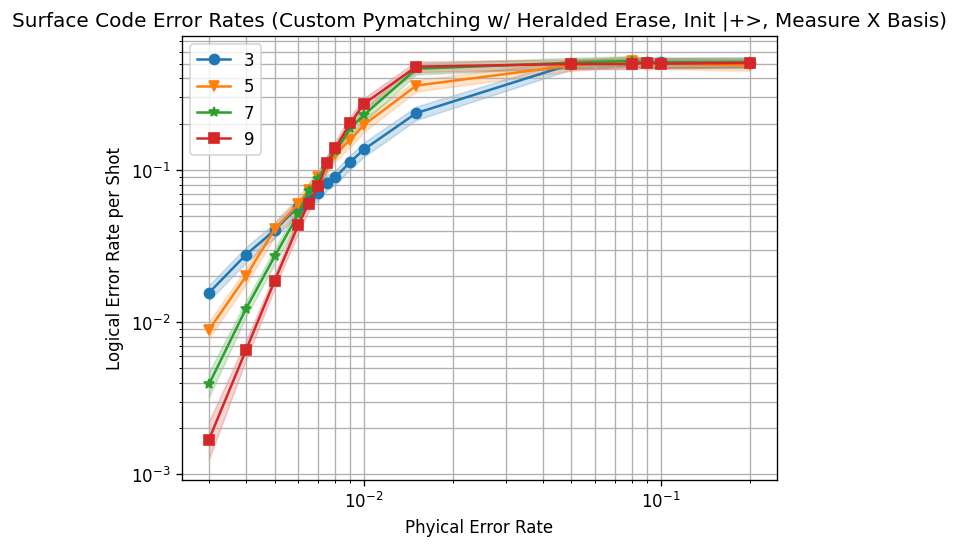

In [4]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=pymatching_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: stats.json_metadata["d"],
)
# ax.set_ylim(1e-6, 1e0)
# ax.set_xlim(1e-2, 2e-1)
ax.loglog()
ax.set_title(
    "Surface Code Error Rates (Custom Pymatching w/ Heralded Erase, Init |+>, Measure X Basis)"
)
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)

In [ ]:
import sinter
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use("plotstyles.mlpstyle")

PYMATCHING_FILES = [
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=HeraldedEraseDecoder/erasure=1.0/2025-11-30_pthresh.csv"
]
custom_stats = sinter.read_stats_from_csv_files(*PYMATCHING_FILES)

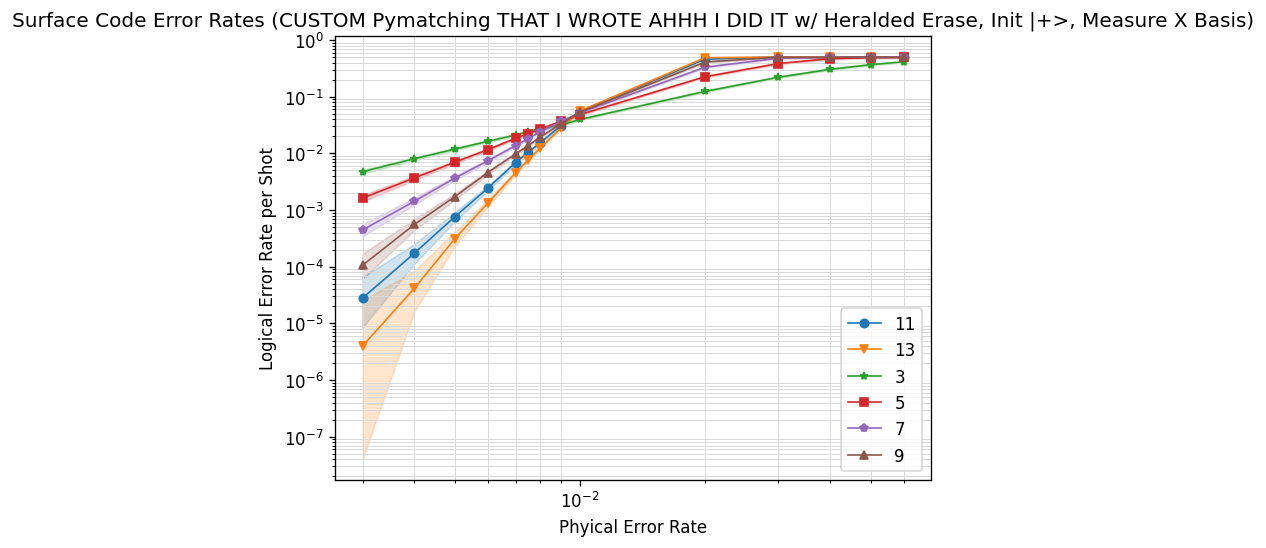

In [22]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=custom_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: stats.json_metadata["d"],
)
# ax.set_ylim(1e-6, 1e0)
# ax.set_xlim(1e-2, 2e-1)
ax.loglog()
ax.set_title(
    "Surface Code Error Rates (CUSTOM Pymatching THAT I WROTE AHHH I DID IT w/ Heralded Erase, Init |+>, Measure X Basis)"
)
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)

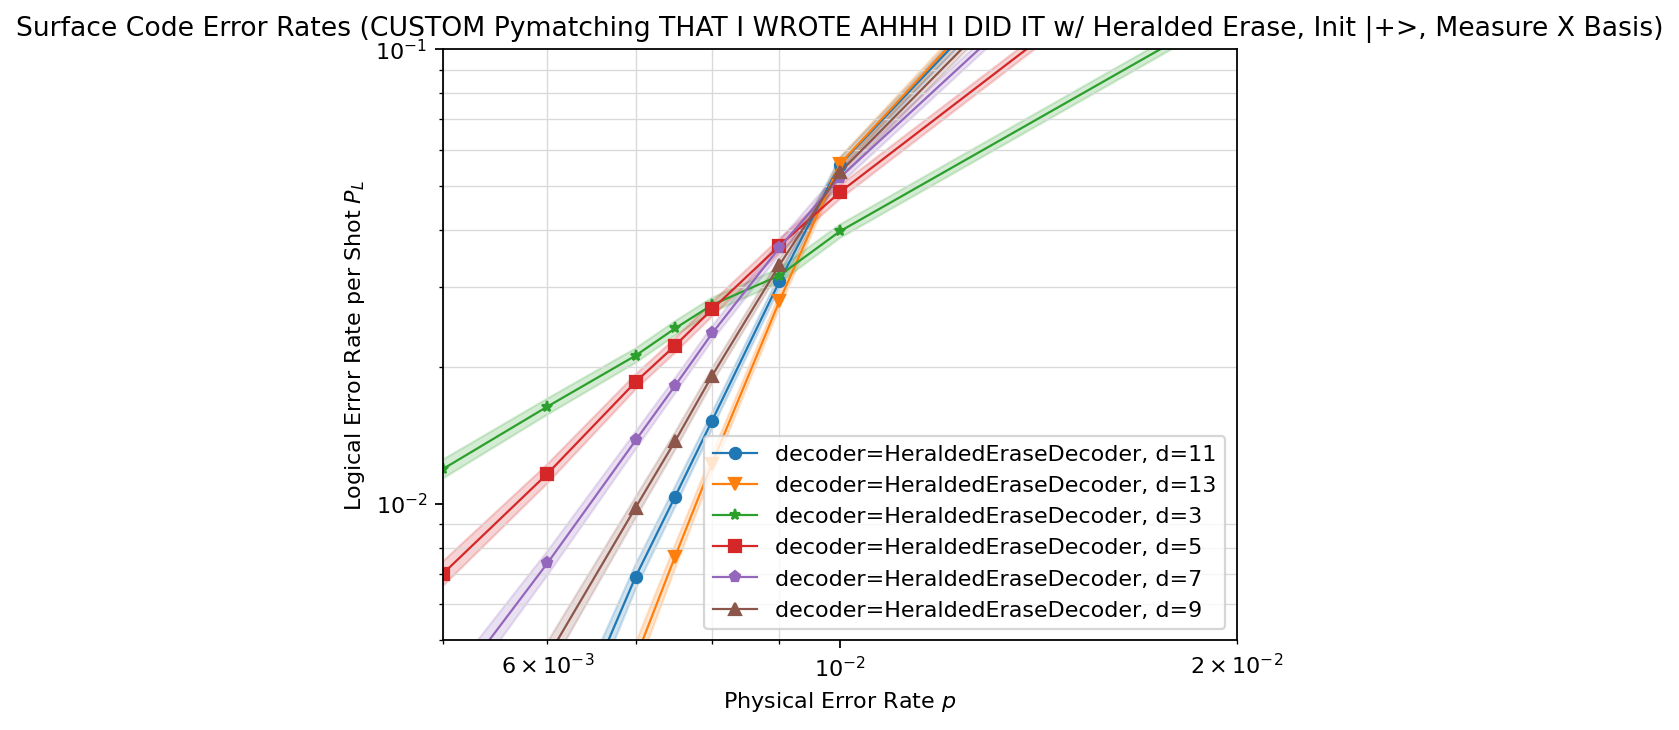

In [25]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=custom_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: "decoder="
    + stats.json_metadata["decoder"]
    + ", d="
    + str(stats.json_metadata["d"]),
)
ax.loglog()
ax.set_title(
    "Surface Code Error Rates (CUSTOM Pymatching THAT I WROTE AHHH I DID IT w/ Heralded Erase, Init |+>, Measure X Basis)"
)
ax.set_ylim(5e-3, 1e-1)
ax.set_xlim(5e-3, 2e-2)
# plt.axvspan(5e-3, 9e-3, color="silver", label="Zoomed region", alpha=0.3)
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $P_L$")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(160)